# 10 — Lesions redefined, lesion trajectories, and what the stains add to them

Mouse EAE spinal cord, **all five RRMAP2 runs** (transcriptome: 1.38 M cells, 61 animals; images: runs 5/6 for now).

**Why.** The curated niche labels (`Curated_niche_state`) are transcriptome clusters. They call 6–13 % of cells in
never-immunised controls "Lesion_mix", and remission animals still carry 40–80 % "lesion", so we can't tell resolving
from active tissue. Here:

- **A.** Audit of the current labels.
- **B.** **Control-referenced lesions.** Each cell's 30-cell neighbourhood is described by cell-type mix, disease
  programs and cellularity. A neighbourhood is lesioned when it lies outside what control animals of the same region
  (WM / GM / meninges) show. The threshold is calibrated so held-out control animals are ~1 % lesion.
- **C.** **Lesion states** from interpretable axes (infiltration, monocyte-derived myeloid, lipid-associated myeloid,
  glial reactivity, oligodendrocyte disease state, tissue loss, fibrosis, cellularity), and how their share moves
  along both disease courses (onset → peak → remission / monophasic; chronic mild vs severe).
- **D.** **Image pilot (runs 5/6).** Does the same lesion state look different in the stains at peak vs in
  remission? Is neuropil restored as lesions resolve, or is there persistent damage (neuropil loss, vimentin scar)?

Statistical unit = animal. Stage groups follow the disease-course plots: controls (CFA, MOG/PLP CFA, non-symptomatic),
onset (OS1, ONSET1/2), peak (PEAK1/2/3, PEAK2_MILD), chronic late (MILD16/30, SEVERE16/30; MILD30 is a separate batch
= run1), recovery (REMISSION1/2/2_LONG, MONOPHASIC).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.cluster import KMeans
from sklearn.covariance import LedoitWolf

from beyondboundaries import plotting

plotting.style()
SRC = "notebooks/10_lesion_states.ipynb"
OUT = ROOT / "results" / "10_lesion_states"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "data" / "lesion10"
CACHE.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)

GROUP = {"CFA": "control", "MOG CFA": "control", "PLP CFA": "control", "NONSYMPTOM": "control",
         "OS1": "onset", "ONSET1": "onset", "ONSET2": "onset",
         "PEAK1": "peak", "PEAK2": "peak", "PEAK2_MILD": "peak", "PEAK3": "peak",
         "MILD16": "chronic late", "SEVERE16": "chronic late", "MILD30": "chronic late", "SEVERE30": "chronic late",
         "REMISSION1": "recovery", "REMISSION2": "recovery", "REMISSION2_LONG": "recovery", "MONOPHASIC": "recovery"}
GROUP_ORDER = ["control", "onset", "peak", "chronic late", "recovery"]
GCOL = dict(zip(GROUP_ORDER, ["#888888", plotting.CATEGORICAL[3], plotting.CATEGORICAL[1], plotting.CATEGORICAL[5],
                              plotting.CATEGORICAL[2]]))
# ordered by day post-induction (RRMAP timepoint tables); MONOPHASIC is sacrificed on the same days as PEAK2 (32-33)
RR_ORDER = ["PLP CFA", "ONSET1", "ONSET2", "PEAK1", "REMISSION1", "PEAK2_MILD", "PEAK2", "MONOPHASIC", "PEAK3",
            "REMISSION2", "REMISSION2_LONG"]
CH_ORDER = ["MOG CFA", "NONSYMPTOM", "CFA", "OS1", "PEAK1", "MILD16", "SEVERE16", "SEVERE30", "MILD30"]

In [2]:
adata = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad")
obs = adata.obs
obs["run"] = obs.run_id.astype(str)
obs["stage"] = obs.stage.astype(str)
obs["group"] = obs.stage.map(GROUP)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
REG = {"WM": "WM", "WM_Meningeal": "WM", "GM": "GM", "DorsalHorn": "GM", "VentralHorn": "GM", "Meninges": "meninges"}
obs["region_class"] = obs.Global_anatomical_region.astype(str).map(REG).fillna("other")
animals = obs.groupby("sample_name", observed=True).agg(run=("run", "first"), arm=("arm", "first"),
                                                         stage=("stage", "first"), group=("group", "first"),
                                                         score=("score_sacrifice", "first"),
                                                         day=("day_of_sacrifice", "first"), cells=("run", "size"))
print(adata.shape, "|", len(animals), "animals")
animals.groupby(["arm", "group"]).size().unstack(0)

(1384881, 5101) | 67 animals


arm,RR,chronic
group,,
chronic late,NaN,13.0
control,3.0,10.0
onset,4.0,5.0
peak,13.0,6.0
recovery,13.0,NaN


## A. Audit of the current lesion labels

In [3]:
obs["old_lesion"] = obs.Curated_niche_state.astype(str).str.startswith("Lesion")
old = pd.crosstab(obs.sample_name, obs.Curated_niche_state.astype(str), normalize="index")
old["any lesion"] = old.filter(like="Lesion").sum(1)
old = old.join(animals)
print("controls, share of cells labelled lesion (per animal):")
print(old[old.group == "control"][["run", "stage", "Lesion_mix", "any lesion"]].round(3).to_string())
pd.crosstab(obs.Global_anatomical_region.astype(str), obs.Curated_niche_state.astype(str), normalize="index").round(2)

controls, share of cells labelled lesion (per animal):
              run       stage  Lesion_mix  any lesion
sample_name                                          
C_CFA_1      run1     MOG CFA       0.046       0.047
C_CFA_2      run1     MOG CFA       0.087       0.088
C_CFA_3      run1     MOG CFA       0.061       0.071
C_CFA_4      run5         CFA       0.078       0.082
C_CFA_6      run5         CFA       0.179       0.180
C_NS_1       run1  NONSYMPTOM       0.062       0.066
C_NS_2       run1  NONSYMPTOM       0.052       0.053
C_NS_3       run1  NONSYMPTOM       0.111       0.127
C_NS_4       run5  NONSYMPTOM       0.074       0.077
C_NS_5       run5  NONSYMPTOM       0.039       0.040
RR_CFA_1     run2     PLP CFA       0.081       0.081
RR_CFA_2     run2     PLP CFA       0.097       0.099
RR_CFA_3     run3     PLP CFA       0.082       0.083


Curated_niche_state,Lesion_active,Lesion_mix,Lesion_progressive,Lesion_reactive,Meninges,Physiological,Vasculature
Global_anatomical_region,,,,,,,
Central_canal,0.00,0.00,0.00,0.0,0.00,1.00,0.00
DRG,0.16,0.18,0.00,0.0,0.00,0.65,0.00
DorsalHorn,0.18,0.08,0.00,0.1,0.00,0.64,0.00
GM,0.18,0.09,0.23,0.0,0.00,0.50,0.00
Meninges,0.16,0.24,0.39,0.0,0.09,0.11,0.00
Unassigned,1.00,0.00,0.00,0.0,0.00,0.00,0.00
Vasculature,0.00,0.25,0.38,0.0,0.00,0.00,0.37
VentralHorn,0.00,0.00,0.56,0.0,0.00,0.44,0.00
WM,0.31,0.27,0.18,0.0,0.00,0.23,0.00


The anatomical region labels cover lesions too (lesion niches fall into WM / GM / meninges, not "Unassigned"; table
above), so they can serve as the reference stratum. DRG, vasculature, central canal and unassigned cells are left out.

## B. Control-referenced lesions

**Neighbourhood vector** for every cell (30 nearest cells in the same tissue piece, including itself):
- composition over 24 cell types/states (L2 where it carries disease state: reactive astrocytes, DAO, MDM, EAE-
  associated fibroblasts…),
- neighbourhood mean of 7 gene programs (per-cell score = mean of gene-wise z of log-normalised expression),
- log cellularity (cells per 1000 µm² within the 30-NN radius).

In [4]:
TYPES = {
    "Microglia": ("Anno_L2", ["Microglia"]), "MDM": ("Anno_L2", ["MDM"]), "CAM": ("Anno_L2", ["CAM"]),
    "DC": ("Anno_L1_curated", ["DC"]), "NK/DC": ("Anno_L1_curated", ["NK/DC"]),
    "T cell": ("Anno_L1_curated", ["T cell"]), "B cell": ("Anno_L1_curated", ["B cell"]),
    "Neutrophil": ("Anno_L1_curated", ["Neutrophil"]),
    "Homeostatic astro": ("Anno_L2", ["Homo_AST", "Myelin_AST", "Neurovascular_AST"]),
    "Reactive astro": ("Anno_L2", ["Reactive_AST"]),
    "MOL": ("Anno_L2", ["MOL"]), "NFOL": ("Anno_L2", ["NFOL"]), "DAO": ("Anno_L2", ["DAO"]),
    "OPC/COP": ("Anno_L2", ["OPC/COP"]),
    "Exc neuron": ("Anno_L2", ["Exc"]), "Inh neuron": ("Anno_L2", ["Inh", "Chol/Inh"]), "Chol neuron": ("Anno_L2", ["Chol"]),
    "Endothelial": ("Anno_L1_curated", ["Endothelial"]), "VSMC": ("Anno_L1_curated", ["VSMC"]),
    "EAE fibroblast": ("Anno_L2", ["EAE - Associated FBs", "Meningeal EAE FBs"]),
    "Fibroblast": ("Anno_L2", ["Fibroblast", "Meningeal FBs", "Meningeal/Perivascular FBs", "Perineural FBs"]),
    "Schwann": ("Anno_L1_curated", ["Schwann cell"]), "Ependymal": ("Anno_L1_curated", ["Ependymal cell"]),
}
ctype = pd.Series("other", index=obs.index)
for name, (col, vals) in TYPES.items():
    # fibroblast L1 contains mislabelled T/B cells in L2 -> those stay in their L2 class
    m = obs[col].astype(str).isin(vals)
    if name in ("T cell", "B cell"):
        m |= obs.Anno_L2.astype(str).isin(["CD4+ T Cell", "CD8+ T Cell", "T Cell"] if name == "T cell" else ["B Cell"])
    ctype[m & (ctype == "other")] = name
obs["ctype"] = ctype
print(obs.ctype.value_counts().to_string())

ctype
MOL                  145307
Microglia            131287
Exc neuron           117490
Endothelial          112244
Fibroblast           109778
DAO                   88830
Inh neuron            83152
Homeostatic astro     72109
MDM                   69995
Reactive astro        69490
DC                    60927
Schwann               58598
T cell                50487
OPC/COP               50310
NFOL                  42316
VSMC                  28729
EAE fibroblast        26725
other                 16073
B cell                14811
CAM                   13198
Ependymal              9158
Chol neuron            7335
NK/DC                  6173
Neutrophil              359


In [5]:
PROGRAMS = {
    "lipid-assoc. myeloid": ["Trem2", "Lpl", "Cd36", "Gpnmb", "Igf1", "Itgax", "Cst7", "Cd9", "Plin2", "Abca1", "Ch25h",
                             "Msr1"],
    "MHC-II": ["H2-Aa", "H2-Ab1", "H2-Eb1", "Cd74"],
    "interferon": ["Ifit1", "Ifit3", "Isg15", "Irf7", "Stat1", "Oasl2", "Rsad2"],
    "astro reactive": ["C3", "Gfap", "Serpina3n", "Cd44", "Osmr", "Timp1", "Socs3", "Serping1"],
    "homeostatic microglia": ["P2ry12", "Tmem119", "Sall1", "Cx3cr1", "Siglech"],
    "myelin": ["Mbp", "Mog", "Mag", "Cldn11", "Mal", "Opalin"],
    "ECM / fibrosis": ["Col1a1", "Col1a2", "Fn1", "Tnc", "Postn", "Col3a1"],
}
gi = {g: i for i, g in enumerate(adata.var_names)}
X = adata.X.tocsc()
prog = pd.DataFrame(index=obs.index)
for p, genes in PROGRAMS.items():
    gs = [g for g in genes if g in gi]
    M = X[:, [gi[g] for g in gs]].toarray()
    prog[p] = ((M - M.mean(0)) / M.std(0)).mean(1)
    print(f"{p}: {len(gs)}/{len(genes)} genes ({', '.join(g for g in genes if g not in gi) or 'all present'} missing)")
del X

lipid-assoc. myeloid: 12/12 genes (all present missing)
MHC-II: 4/4 genes (all present missing)
interferon: 6/7 genes (Rsad2 missing)
astro reactive: 8/8 genes (all present missing)
homeostatic microglia: 5/5 genes (all present missing)
myelin: 6/6 genes (all present missing)


ECM / fibrosis: 5/6 genes (Col3a1 missing)


In [6]:
K = 30
NB_TYPES = list(TYPES)
cache_nb = CACHE / "neighbourhoods.parquet"
if cache_nb.exists():
    nb = pd.read_parquet(cache_nb)
else:
    onehot = pd.get_dummies(obs.ctype).reindex(columns=NB_TYPES, fill_value=False).to_numpy(np.float32)
    P = prog.to_numpy(np.float32)
    comp = np.zeros((len(obs), len(NB_TYPES)), np.float32)
    pm = np.zeros((len(obs), P.shape[1]), np.float32)
    dens = np.zeros(len(obs), np.float32)
    for _, idx in obs.groupby("meta_sample_id", observed=True).indices.items():
        xy = obs[["x_centroid", "y_centroid"]].to_numpy()[idx]
        k = min(K, len(idx))
        d, nn = cKDTree(xy).query(xy, k=k)
        comp[idx] = onehot[idx][nn].mean(1)
        pm[idx] = P[idx][nn].mean(1)
        dens[idx] = k / (np.pi * np.maximum(d[:, -1], 1) ** 2) * 1000
    nb = pd.concat([pd.DataFrame(comp, index=obs.index, columns=[f"frac {t}" for t in NB_TYPES]),
                    pd.DataFrame(pm, index=obs.index, columns=[f"prog {p}" for p in PROGRAMS]),
                    pd.Series(np.log(dens), index=obs.index, name="log cellularity")], axis=1)
    nb.to_parquet(cache_nb)
FEATS = list(nb.columns)
nb.describe().T[["mean", "50%", "max"]].round(3).head(8)

,mean,50%,max
frac Microglia,0.093,0.067,0.833
frac MDM,0.052,0.000,1.000
frac CAM,0.010,0.000,0.567
frac DC,0.046,0.000,0.833
frac NK/DC,0.005,0.000,0.600
frac T cell,0.038,0.000,0.900
frac B cell,0.012,0.000,1.000
frac Neutrophil,0.000,0.000,0.433


**Abnormality.** Per region class: features standardised by the control neighbourhoods (mean / SD, SD floored so
that a type absent in controls doesn't explode), then the squared Mahalanobis distance to the control cloud (Ledoit-Wolf
covariance). **Calibration: leave one control animal out.** Each control animal is scored against the other
controls; the lesion threshold is the 99th percentile of those held-out distances. So a new control animal is
expected to be ~1 % "lesion" by construction, and every other animal is scored against all controls.

In [7]:
CTRL = obs.group == "control"
SD_FLOOR = 0.02


def fit_ref(Xc):
    mu, sd = Xc.mean(0), np.maximum(Xc.std(0), SD_FLOOR)
    lw = LedoitWolf().fit((Xc - mu) / sd)
    return mu, sd, lw


def maha(Xa, ref):
    mu, sd, lw = ref
    return lw.mahalanobis((Xa - mu) / sd)


abn = pd.Series(np.nan, index=obs.index)
thr = {}
for rc in ["WM", "GM", "meninges"]:
    sel = (obs.region_class == rc).to_numpy()
    Xr = nb.loc[sel, FEATS].to_numpy(np.float64)
    ctrl = CTRL.to_numpy()[sel]
    an = obs.sample_name.astype(str).to_numpy()[sel]
    held = []
    for a in np.unique(an[ctrl]):
        tr = ctrl & (an != a)
        sub = np.flatnonzero(tr)
        sub = rng.choice(sub, min(len(sub), 60000), replace=False)
        held.append(maha(Xr[an == a], fit_ref(Xr[sub])))
    thr[rc] = np.quantile(np.concatenate(held), 0.99)
    sub = np.flatnonzero(ctrl)
    ref = fit_ref(Xr[rng.choice(sub, min(len(sub), 60000), replace=False)])
    abn[obs.index[sel]] = maha(Xr, ref)
    # controls keep their held-out distance
    for a, h in zip(np.unique(an[ctrl]), held):
        abn[obs.index[sel][an == a]] = h
    print(f"{rc}: threshold d² = {thr[rc]:.1f}")
obs["abnormality"] = abn
obs["new_lesion"] = obs.abnormality > obs.region_class.map(thr)
obs.loc[obs.region_class == "other", "new_lesion"] = np.nan

WM: threshold d² = 298.2


GM: threshold d² = 331.3


meninges: threshold d² = 180.0


/tmp/ipykernel_22641/804363832.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  obs.loc[obs.region_class == "other", "new_lesion"] = np.nan


lesion share per animal, median by group:
                old       new
group                        
control       0.081  0.008772
onset         0.583  0.350941
peak          0.952  0.858266
chronic late  0.628  0.328199
recovery      0.599  0.358712


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/10_lesion_states/lesion_share_old_vs_new.png')

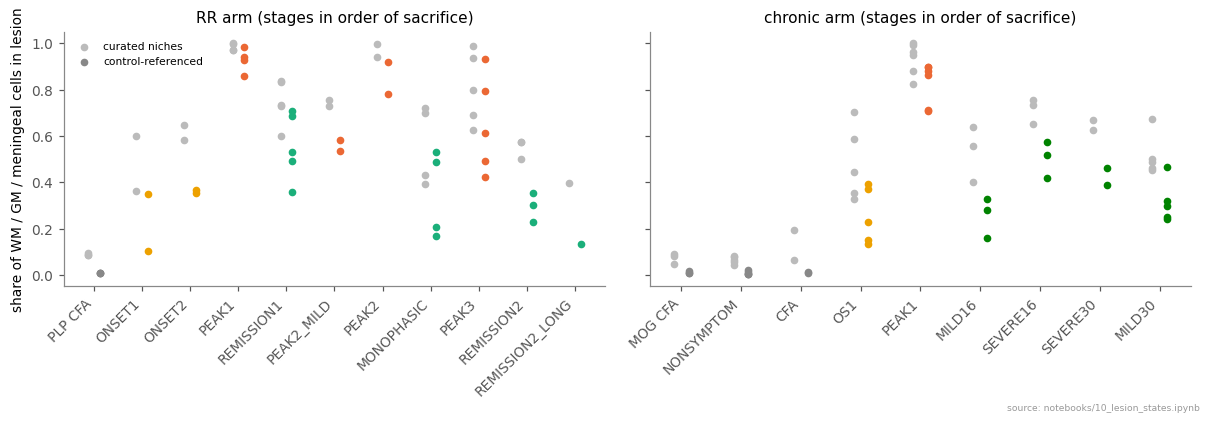

In [8]:
nl = obs[obs.region_class != "other"].groupby("sample_name", observed=True).agg(
    new=("new_lesion", "mean"), old=("old_lesion", "mean")).join(animals)
print("lesion share per animal, median by group:")
print(nl.groupby("group")[["old", "new"]].median().reindex(GROUP_ORDER).round(3).to_string())
nl.to_csv(OUT / "lesion_share_per_animal.csv")
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, arm, order in zip(axs, ["RR", "chronic"], [RR_ORDER, CH_ORDER]):
    d = nl[nl.arm == arm]
    st = [s for s in order if s in set(d.stage)]
    for k, s in enumerate(st):
        g = d[d.stage == s]
        ax.scatter(np.full(len(g), k) - 0.12, g.old, s=16, color="#bbbbbb", label="curated niches" if k == 0 else None)
        ax.scatter(np.full(len(g), k) + 0.12, g.new, s=16, color=GCOL[g.group.iloc[0]],
                   label="control-referenced" if k == 0 else None)
    ax.set_xticks(range(len(st)), st, rotation=45, ha="right")
    ax.set_title(f"{arm} arm (stages in order of sacrifice)")
axs[0].set_ylabel("share of WM / GM / meningeal cells in lesion")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "lesion_share_old_vs_new", OUT, SRC)

In [9]:
pd.crosstab(obs.Curated_niche_state.astype(str), obs.new_lesion, normalize="index").round(2)

new_lesion,False,True
Curated_niche_state,,
Lesion_active,0.06,0.94
Lesion_mix,0.72,0.28
Lesion_progressive,0.19,0.81
Lesion_reactive,0.52,0.48
Meninges,0.89,0.11
Physiological,0.96,0.04


## C. Lesion states

Interpretable axes per neighbourhood, each a z-score against control neighbourhoods of the same region class
(positive = more than in controls):

In [10]:
AXES = {
    "infiltration": ["frac T cell", "frac B cell", "frac NK/DC", "frac Neutrophil"],
    "monocyte-derived myeloid": ["frac MDM", "frac DC"],
    "lipid-assoc. myeloid": ["prog lipid-assoc. myeloid"],
    "MHC-II / IFN": ["prog MHC-II", "prog interferon"],
    "astro reactivity": ["prog astro reactive", "frac Reactive astro"],
    "oligo disease state": ["frac DAO"],
    "myelinating oligo loss": ["frac MOL", "prog myelin"],      # sign flipped below
    "microglia homeostasis loss": ["prog homeostatic microglia"],  # sign flipped below
    "fibrosis": ["frac EAE fibroblast", "prog ECM / fibrosis"],
    "cellularity": ["log cellularity"],
}
FLIP = {"myelinating oligo loss", "microglia homeostasis loss"}
zf = pd.DataFrame(index=obs.index, columns=FEATS, dtype=np.float32)
for rc in ["WM", "GM", "meninges"]:
    sel = obs.region_class == rc
    c = nb.loc[sel & CTRL, FEATS]
    zf.loc[sel] = ((nb.loc[sel, FEATS] - c.mean()) / np.maximum(c.std(), SD_FLOOR)).to_numpy(np.float32)
ax_ = pd.DataFrame({a: zf[cols].mean(1) * (-1 if a in FLIP else 1) for a, cols in AXES.items()})
ax_ = ax_.clip(-10, 30)

States = k-means (k = 6) on the axes of control-referenced lesion neighbourhoods (up to 400k sampled for the fit,
then all assigned). k is a resolution choice, not a claim that there are exactly six states; profiles below show
what each one is.

In [11]:
LES = obs.new_lesion.fillna(False).astype(bool)
A = ax_[LES].to_numpy()
fit_idx = rng.choice(len(A), min(len(A), 400_000), replace=False)
km = KMeans(6, n_init=10, random_state=0).fit(np.arcsinh(A[fit_idx]))
lab = km.predict(np.arcsinh(A))
prof = ax_[LES].groupby(lab).median()
prof["share of lesion cells"] = pd.Series(lab).value_counts(normalize=True).sort_index().values
prof.round(2)

/tmp/ipykernel_22641/1431647972.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  LES = obs.new_lesion.fillna(False).astype(bool)


,infiltration,monocyte-derived myeloid,lipid-assoc. myeloid,MHC-II / IFN,astro reactivity,oligo disease state,myelinating oligo loss,microglia homeostasis loss,fibrosis,cellularity,share of lesion cells
0,-0.01,0.81,6.50,7.68,4.70,4.82,0.63,-1.98,0.24,0.19,0.20
1,1.23,9.89,8.94,9.19,1.84,-0.82,2.67,1.03,2.46,4.45,0.26
2,0.82,0.72,9.08,5.46,2.98,1.76,2.18,-0.57,2.66,2.60,0.13
3,-0.01,0.72,3.73,7.77,3.21,-0.18,0.62,-1.94,0.02,0.50,0.11
4,1.23,7.39,7.69,7.77,2.25,2.62,2.08,-0.06,0.76,2.26,0.18
5,2.00,0.81,1.66,2.18,1.05,-0.51,0.97,0.25,0.84,1.36,0.11


lesion_state,S0: astro reactivity + oligo disease state,S1: monocyte-derived myeloid + microglia homeostasis loss,S2: fibrosis + myelinating oligo loss,S3: astro reactivity + MHC-II / IFN,S4: monocyte-derived myeloid + oligo disease state,S5: infiltration + microglia homeostasis loss,no lesion,not scored
Curated_niche_state,,,,,,,,
Lesion_active,0.14,0.36,0.03,0.04,0.19,0.06,0.05,0.13
Lesion_mix,0.10,0.00,0.05,0.04,0.03,0.03,0.65,0.09
Lesion_progressive,0.16,0.10,0.19,0.11,0.12,0.11,0.19,0.03
Lesion_reactive,0.05,0.00,0.05,0.30,0.01,0.06,0.52,0.00
Meninges,0.01,0.00,0.00,0.03,0.00,0.07,0.89,0.00
Physiological,0.00,0.00,0.00,0.02,0.00,0.01,0.84,0.13
Vasculature,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


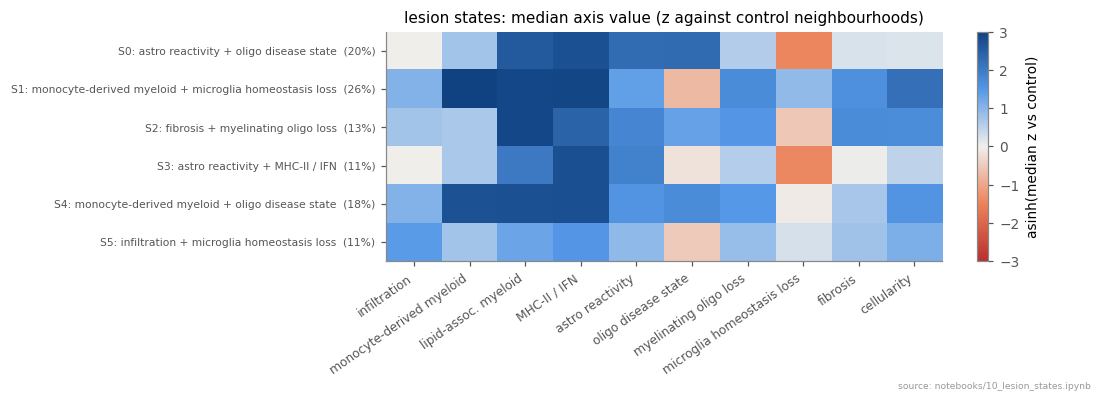

In [12]:
# Every lesion state is far above control on the myeloid / MHC-II axes, so naming by the largest axis repeats itself.
# Name each state by the two axes that most distinguish it from the other states (profile z-scored across states).
rel = np.arcsinh(prof.drop(columns="share of lesion cells"))
rel = (rel - rel.mean()) / rel.std()
names = {k: f"S{k}: " + " + ".join(rel.loc[k].sort_values(ascending=False).index[:2]) for k in prof.index}
obs["lesion_state"] = "no lesion"
obs.loc[LES, "lesion_state"] = pd.Series(lab, index=obs.index[LES]).map(names)
obs.loc[obs.region_class == "other", "lesion_state"] = "not scored"
STATES = [names[k] for k in prof.index]

fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(np.arcsinh(prof.drop(columns="share of lesion cells").to_numpy()), cmap=plotting.DIV.reversed(),
               vmin=-3, vmax=3, aspect="auto")
ax.set_yticks(range(len(prof)), [f"{names[k]}  ({prof.loc[k, 'share of lesion cells']:.0%})" for k in prof.index],
              fontsize=7)
ax.set_xticks(range(len(AXES)), list(AXES), rotation=35, ha="right", fontsize=8)
fig.colorbar(im, ax=ax, label="asinh(median z vs control)")
ax.set_title("lesion states: median axis value (z against control neighbourhoods)")
fig.tight_layout()
plotting.save_fig(fig, "lesion_state_profiles", OUT, SRC)
pd.crosstab(obs.Curated_niche_state.astype(str), obs.lesion_state, normalize="index").round(2)

**Trajectories.** Share of each lesion state per animal (of WM / GM / meningeal cells), along both disease courses.

,S0: astro reactivity + oligo disease state,S1: monocyte-derived myeloid + microglia homeostasis loss,S2: fibrosis + myelinating oligo loss,S3: astro reactivity + MHC-II / IFN,S4: monocyte-derived myeloid + oligo disease state,S5: infiltration + microglia homeostasis loss
group,,,,,,
control,0.001,0.000,0.001,0.001,0.000,0.007
onset,0.056,0.058,0.043,0.030,0.033,0.044
peak,0.162,0.287,0.029,0.074,0.168,0.064
chronic late,0.072,0.018,0.122,0.032,0.029,0.043
recovery,0.069,0.057,0.079,0.053,0.031,0.057


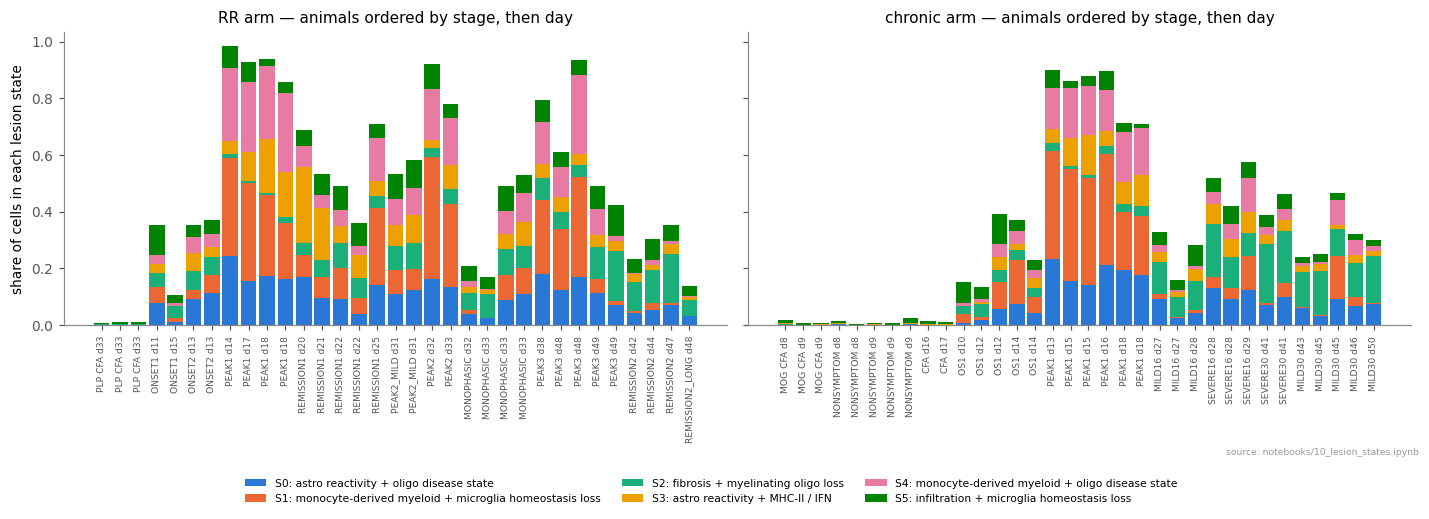

In [13]:
sh = pd.crosstab(obs.loc[obs.region_class != "other", "sample_name"],
                 obs.loc[obs.region_class != "other", "lesion_state"], normalize="index").join(animals)
sh.to_csv(OUT / "lesion_state_share_per_animal.csv")
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, arm, order in zip(axs, ["RR", "chronic"], [RR_ORDER, CH_ORDER]):
    d = sh[sh.arm == arm].copy()
    d["o"] = d.stage.map({s: i for i, s in enumerate(order)})
    d = d.sort_values(["o", "day"])
    bottom = np.zeros(len(d))
    for k, s in enumerate(STATES):
        ax.bar(np.arange(len(d)), d[s], bottom=bottom, color=plotting.CATEGORICAL[k % 8], width=0.85,
               label=s if arm == "RR" else None)
        bottom += d[s].to_numpy()
    ax.set_xticks(np.arange(len(d)), [f"{s} d{int(dy)}" for s, dy in zip(d.stage, d.day)], rotation=90, fontsize=6)
    ax.set_title(f"{arm} arm — animals ordered by stage, then day")
axs[0].set_ylabel("share of cells in each lesion state")
fig.legend(fontsize=7, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plotting.save_fig(fig, "lesion_state_trajectories", OUT, SRC)
sh.groupby("group")[STATES].median().reindex(GROUP_ORDER).round(3)

In [14]:
obs[["region_class", "abnormality", "new_lesion", "lesion_state", "ctype"]].assign(
    new_lesion=lambda d: d.new_lesion.astype(float)).to_parquet(CACHE / "lesion_calls.parquet")
ax_.to_parquet(CACHE / "lesion_axes.parquet")

## D. Image pilot (runs 5/6): the same lesion state at peak vs in recovery

Image readouts per cell (normalised features from notebook 02, 18S-segmented cells):
- **neuropil index** — ATP1A1 in the 10 µm territory ÷ the median of the same piece's *non-lesion* WM or GM
  (pieces with ≥ 100 non-lesion cells of that class),
- **tissue vimentin/αSMA** — channel mean in the territory, robust z within image,
- **astrocyte vimentin** — channel cell mean in astrocytes, robust z within image,
- **18S texture** — Haralick correlation in myeloid cells, robust z within image.

Per animal and lesion state: median readout. Within each state, peak vs recovery animals.

In [15]:
fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]
fa = fa.join(obs[["lesion_state", "group", "region_class", "ctype"]].rename(columns={"region_class": "rc10"}),
             how="inner")
print(len(fa), "cells with image features and new lesion calls")


def image_z(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


fa["bnd_terr_raw"] = fa.bnd_terr_mean * fa.bnd_scale + fa.bnd_bg_local
wmgm = fa.rc10.isin(["WM", "GM"])
key = fa.meta_sample_id.astype(str) + "|" + fa.rc10
# reference = the piece's own non-lesion tissue of the same class (WM / GM): in a mostly lesioned piece the piece
# median is itself lesion and would hide the loss (notebook 06 used the piece median over all cells)
ref = fa.bnd_terr_raw.where(fa.lesion_state == "no lesion").groupby(key).agg(["median", "count"])
ref = ref[ref["count"] >= 100]["median"]
fa["neuropil index"] = np.where(wmgm, fa.bnd_terr_raw / key.map(ref), np.nan)
fa["tissue vimentin (z)"] = image_z(fa.smavim_terr_mean, fa.section_id)
fa["astro vimentin (z)"] = np.where(fa.Anno_L1_curated == "Astrocyte",
                                    image_z(fa.smavim_cell_mean.where(fa.Anno_L1_curated == "Astrocyte"), fa.section_id),
                                    np.nan)
fa["myeloid 18S texture (z)"] = np.where(fa.Anno_L1_curated == "Myeloid",
                                         image_z(fa.r18s_glcm_correlation.where(fa.Anno_L1_curated == "Myeloid"),
                                                 fa.section_id), np.nan)
READ = ["neuropil index", "tissue vimentin (z)", "astro vimentin (z)", "myeloid 18S texture (z)"]

pa = fa.groupby(["sample_name", "lesion_state"], observed=True)[READ].median()
pa["n"] = fa.groupby(["sample_name", "lesion_state"], observed=True).size()
pa = pa[pa.n >= 50].reset_index().join(animals[["group", "stage", "score", "day"]], on="sample_name")
pa.to_csv(OUT / "image_readouts_per_animal_state.csv", index=False)
pa.groupby(["lesion_state", "group"])[READ].median().round(2)

481002 cells with image features and new lesion calls


neuropil index  \
lesion_state                                       group                          
S0: astro reactivity + oligo disease state         chronic late            0.98   
                                                   onset                   0.76   
                                                   peak                    1.00   
                                                   recovery                1.07   
S1: monocyte-derived myeloid + microglia homeos... chronic late            1.02   
                                                   onset                   0.83   
                                                   peak                    0.79   
                                                   recovery                0.95   
S2: fibrosis + myelinating oligo loss              chronic late            1.17   
                                                   onset                   0.98   
                                                   peak                    1.06   
                                                   recovery                1.23   
S3: astro reactivity + MHC-II / IFN                chronic late            0.92   
                                                   peak                    0.93   
                                                   recovery                1.05   
S4: monocyte-derived myeloid + oligo disease state chronic late            0.95   
                                                   onset                   0.73   
                                                   peak                    1.05   
                                                   recovery                0.95   
S5: infiltration + microglia homeostasis loss      chronic late            0.90   
                                                   control                 0.97   
                                                   onset                   0.80   
                                                   peak                    0.82   
                                                   recovery                0.94   
no lesion                                          chronic late            1.00   
                                                   control                 1.00   
                                                   onset                   1.00   
                                                   peak                    1.00   
                                                   recovery                1.00   
not scored                                         chronic late             NaN   
                                                   control                  NaN   
                                                   onset                    NaN   
                                                   peak                     NaN   
                                                   recovery                 NaN   

                                                                 tissue vimentin (z)  \
lesion_state                                       group                               
S0: astro reactivity + oligo disease state         chronic late                -0.01   
                                                   onset                       -0.11   
                                                   peak                        -0.06   
                                                   recovery                    -0.01   
S1: monocyte-derived myeloid + microglia homeos... chronic late                 1.33   
                                                   onset                        0.76   
                                                   peak                         1.77   
                                                   recovery                     3.19   
S2: fibrosis + myelinating oligo loss              chronic late                 1.94   
                                                   onset                        0.37   
                    

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/10_lesion_states/image_readouts_by_state_and_group.png')

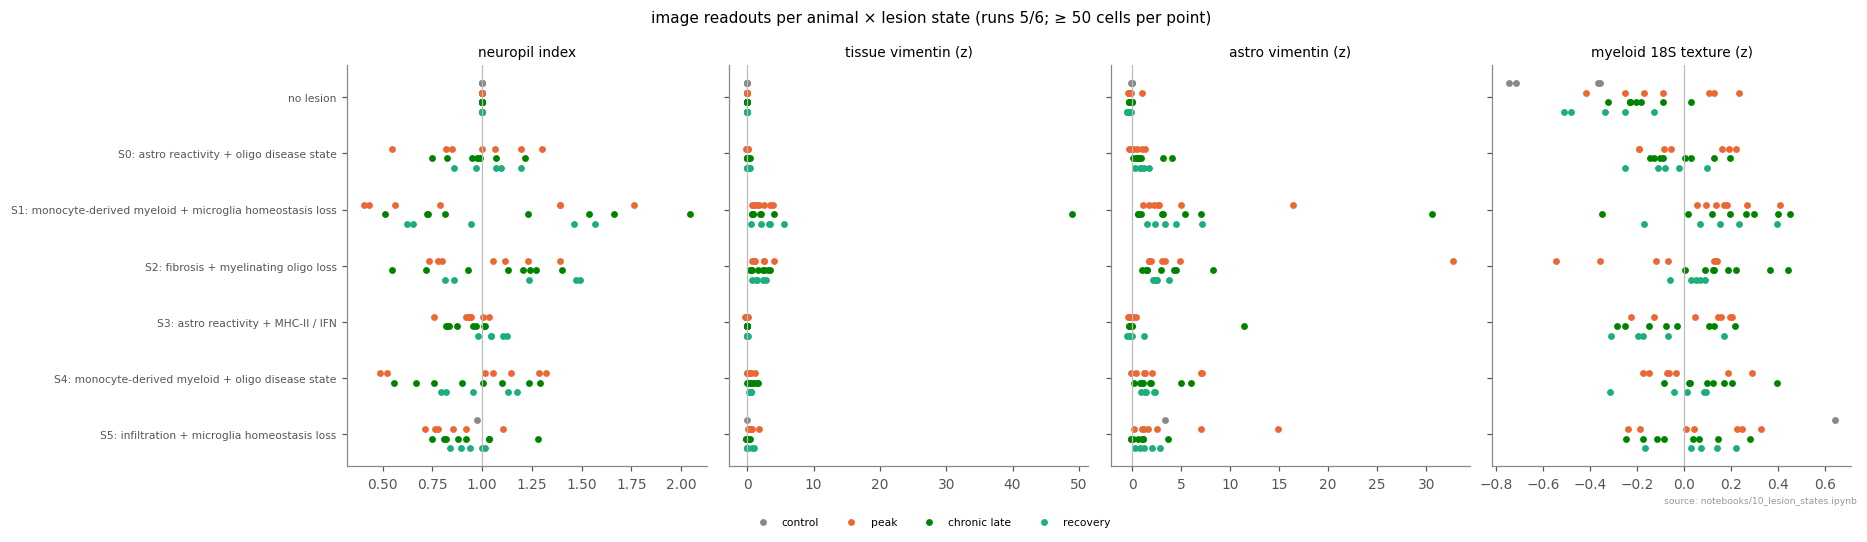

In [16]:
show = ["no lesion"] + STATES
fig, axs = plt.subplots(1, len(READ), figsize=(17, 4.6), sharey=True)
for ax, r in zip(axs, READ):
    for i, s in enumerate(show):
        for j, g in enumerate(["control", "peak", "chronic late", "recovery"]):
            v = pa[(pa.lesion_state == s) & (pa.group == g)][r].dropna()
            if len(v):
                ax.scatter(v, np.full(len(v), i) + (j - 1.5) * 0.17, s=12, color=GCOL[g],
                           label=g if (i == 0 and r == READ[0]) else None)
    ax.set_title(r, fontsize=9)
    ax.axvline(1 if r == "neuropil index" else 0, color="#bbbbbb", lw=0.8)
axs[0].set_yticks(range(len(show)), show, fontsize=7)
axs[0].invert_yaxis()
fig.legend(fontsize=7, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("image readouts per animal × lesion state (runs 5/6; ≥ 50 cells per point)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "image_readouts_by_state_and_group", OUT, SRC)

In [17]:
rows = []
for s in STATES:
    for r in READ:
        p = pa[(pa.lesion_state == s) & (pa.group == "peak")][r].dropna()
        q = pa[(pa.lesion_state == s) & (pa.group == "recovery")][r].dropna()
        if len(p) >= 3 and len(q) >= 3:
            rows.append(dict(state=s, readout=r, peak=p.median(), recovery=q.median(), n_peak=len(p), n_rec=len(q),
                             p=mannwhitneyu(p, q).pvalue))
cmp_ = pd.DataFrame(rows)
cmp_.to_csv(OUT / "peak_vs_recovery_within_state.csv", index=False)
cmp_.round(3)

,state,readout,peak,recovery,n_peak,n_rec,p
0,S0: astro reactivity + oligo disease state,neuropil index,0.999,1.069,7,5,0.530
1,S0: astro reactivity + oligo disease state,tissue vimentin (z),-0.056,-0.006,7,5,0.268
2,S0: astro reactivity + oligo disease state,astro vimentin (z),0.134,0.904,7,5,0.149
3,S0: astro reactivity + oligo disease state,myeloid 18S texture (z),-0.053,-0.079,7,5,0.530
4,S1: monocyte-derived myeloid + microglia homeo...,neuropil index,0.786,0.945,7,5,0.530
5,S1: monocyte-derived myeloid + microglia homeo...,tissue vimentin (z),1.772,3.190,7,5,0.530
6,S1: monocyte-derived myeloid + microglia homeo...,astro vimentin (z),2.614,3.367,7,5,0.755
7,S1: monocyte-derived myeloid + microglia homeo...,myeloid 18S texture (z),0.171,0.152,7,5,0.755
8,S2: fibrosis + myelinating oligo loss,neuropil index,1.056,1.235,7,5,0.202
9,S2: fibrosis + myelinating oligo loss,tissue vimentin (z),1.155,1.456,7,5,0.876
